## Conditional Edge exercise

from learnLanggrpah.practice1 import AgentState

```
Make a graph , use two conditional adge

input: initial_state = AgentState(
                                   number1 =10 ,number2=6, operation1="-"
                                   number3 =15, number4=12, operation2="+",
                                   finalNumber=0, finalNumber2 =1
                                )
```

In [2]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict
from IPython.display import Image, display

In [3]:
class AgentState(TypedDict):
    number1 : int
    number2 : int
    number3 : int
    number4 : int
    operation1 : str
    operation2 : str
    finalNumber1 : int
    finalNumber2 : int


In [4]:
def adder1(state:AgentState)->AgentState:
    """ this adds two numbers """
    state["finalNumber1"] = state["number1"] + state["number2"]
    return state

def adder2(state:AgentState)->AgentState:
    """ this adds two numbers """
    state["finalNumber2"] = state["number3"] + state["number4"]
    return state

def subtractor1(state:AgentState)->AgentState:
    """ this subtracts two numbers """
    state["finalNumber1"] = state["number1"] - state["number2"]
    return state

def subtractor2(state:AgentState)->AgentState:
    """ this subtracts two numbers """
    state["finalNumber2"] = state["number3"] - state["number4"]
    return state

In [5]:
def decide_next_node1(state: AgentState)->AgentState:
    """ this decides the next node to visit """
    if state["operation1"] == "+":
        return "addition_operation_1"
    if state["operation1"] == "-":
        return "subtraction_operation_1"

def decide_next_node2(state: AgentState)->AgentState:
    """ this decides the next node to visit """
    if state["operation2"] == "+":
        return "addition_operation_2"
    if state["operation2"] == "-":
        return "subtraction_operation_2"


In [12]:
graph = StateGraph(AgentState)
graph.add_edge(START, "router1")
graph.add_node("add_node1", adder1)
graph.add_node("subtract_node1", subtractor1)
graph.add_node("router1", lambda state: state)
graph.add_conditional_edges("router1", decide_next_node1, {"addition_operation_1": "add_node1", "subtraction_operation_1":"subtract_node1"})

graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)
graph.add_node("router2", lambda state: state)
graph.add_conditional_edges("router2", decide_next_node2,  {"addition_operation_2": "add_node2", "subtraction_operation_2":"subtract_node2"})
graph.add_edge("add_node1", "router2")
graph.add_edge("subtract_node1", "router2")
graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2",END)
app = graph.compile()

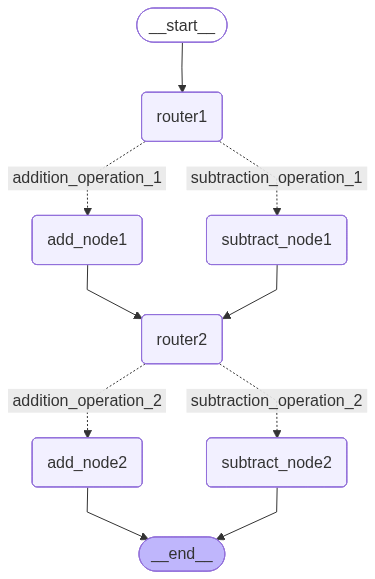

In [14]:
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
init_agenet_1 = AgentState(
    number1 = 0,
    number2 = 1,
    operation1 = "+",
    number3 = 2,
    number4 = 3,
    operation2 = "-",
)

In [16]:
app.invoke(
    init_agenet_1
)

{'number1': 0,
 'number2': 1,
 'number3': 2,
 'number4': 3,
 'operation1': '+',
 'operation2': '-',
 'finalNumber1': 1,
 'finalNumber2': -1}